In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# EDA - Analyse

In [2]:
data_train = pd.read_csv('datas/conversion_data_train.csv')
data_train.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [3]:
data_train.shape

(284580, 6)

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [5]:
data_train.isnull().sum()/len(data_train)*100

country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

In [6]:
data_converted = data_train['converted'].value_counts().reset_index()


fig = px.bar(
    data_converted,
    x='converted',
    y='count',
    labels={'converted': 'Converted (0 = No, 1 = Yes)', 'count': 'Number of users'},
    title='Distribution of Converted Users'
)
fig.show()

In [7]:
data_converted_percent = (round(data_train["converted"].value_counts(normalize=True) * 100, 2)).reset_index()

print(data_converted_percent)

conversion_rate = data_converted_percent.loc[data_converted_percent["converted"] == 1, "proportion"].values[0]
print('The actual convertion rate is', conversion_rate, "%")

   converted  proportion
0          0       96.77
1          1        3.23
The actual convertion rate is 3.23 %


In [8]:
data_age_converted = data_train.groupby("age")["converted"].sum().reset_index()
data_age_converted

fig = px.bar(
    data_age_converted,
    x="age",
    y="converted",
    labels={"age": "Âge", "converted": "Nombre de conversions"},
    title="Nombre de conversions par âge"
)
fig.show()

In [9]:
data_country_converted = data_train.groupby("country")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="country",
    y="converted",
    labels={"country": "Country", "converted": "Nombre de conversions"},
    title="Nombre de conversions par pays"
)
fig.show()

In [10]:
data_country_converted = data_train.groupby("new_user")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="new_user",
    y="converted",
    labels={"new_user": "New user", "converted": "Nombre de conversions"},
    title="Nombre de conversions par nouveaux utilisateurs"
)
fig.show()

In [11]:
data_country_converted = data_train.groupby("source")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="source",
    y="converted",
    labels={"source": "Source", "converted": "Nombre de conversions"},
    title="Nombre de conversions par source"
)
fig.show()

In [12]:
data_country_converted = data_train.groupby("total_pages_visited")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="total_pages_visited",
    y="converted",
    labels={"total_pages_visited": "Total pages visited", "converted": "Nombre de conversions"},
    title="Nombre de conversions par total pages visited"
)
fig.show()

In [13]:
import plotly.figure_factory as ff
numerical_cols = data_train.select_dtypes(include='number')
corr_matrix = numerical_cols.corr()

fig = ff.create_annotated_heatmap(
    z=corr_matrix.values.round(2),
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='Viridis',
    showscale=True
)

fig.update_layout(title="Matrice de corrélation")
fig.show()


# Transform

In [14]:
feature_target = 'converted'
X = data_train.loc[:, data_train.columns != feature_target]
y = data_train[feature_target]

X.head()

,country,age,new_user,source,total_pages_visited
0,China,22,1,Direct,2
1,UK,21,1,Ads,3
2,Germany,20,0,Seo,14
3,US,23,1,Seo,3
4,US,28,1,Direct,3


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [16]:
numeric_features = []
categorical_features = []

for i,t in X_train.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


In [17]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop='first'))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

#model_pipeline = Pipeline(steps=[
 #   ('preprocessor', preprocessor),
  #  ('classifier', LogisticRegression())
#])

#model_pipeline.fit(X_train, y_train)
#model_pipeline.predict(X_test)


In [18]:
#scores = cross_val_score(model_pipeline, X, y, cv=10)
#print("Cross-validated accuracy :", scores.mean())
#print("Standard deviation :", scores.std())

In [19]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=10)
    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Mean Accuracy", ascending=False)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[14:26:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[14:26:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[14:26:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[14:26:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[14:26:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.986211,0.000469
2,XGBoost,0.985881,0.000500
1,Random Forest,0.984756,0.000385


In [20]:
choosed_model = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [15, 20, 25],
    'max_depth': [7, 8, 9],
    'min_samples_split': [3, 4]
}

grid_search = GridSearchCV(
    estimator=choosed_model,
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', grid_search)
])

grid_pipeline.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': 8, 'min_samples_split': 3, 'n_estimators': 25}
Best accuracy: 0.9859535690022725


In [21]:
best_params = grid_pipeline.named_steps['classifier'].best_params_
best_params

{'max_depth': 8, 'min_samples_split': 3, 'n_estimators': 25}

In [22]:
final_model = RandomForestClassifier(**best_params, random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, min_samples_split=3,
                                        n_estimators=25, random_state=42))])

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.87      0.66      0.75      2295

    accuracy                           0.99     71145
   macro avg       0.93      0.83      0.87     71145
weighted avg       0.98      0.99      0.98     71145



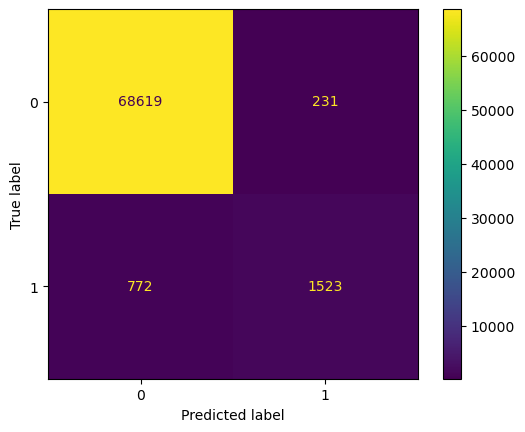

In [24]:
ConfusionMatrixDisplay.from_estimator(final_pipeline, X_test, y_test)

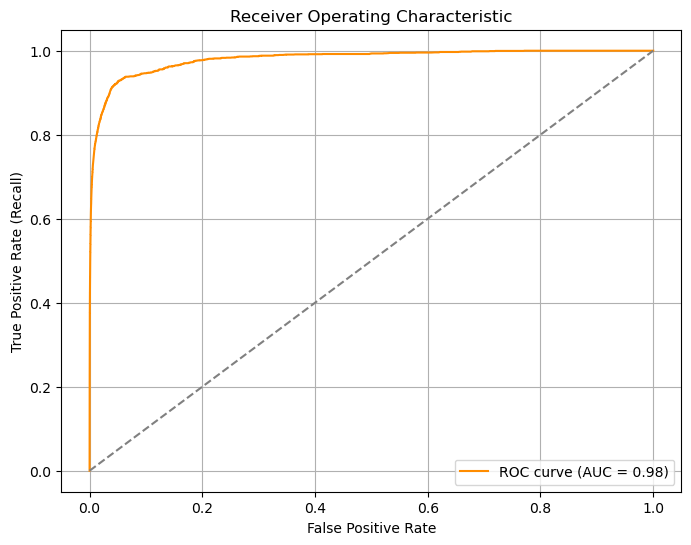

In [25]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_proba = final_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # ligne aléatoire
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()